# 3 - Entrenamiento de Modelos y Exportación ONNX (FinanceAI)

1. Simulación > 2. EDA > **3. Entrenamiento**


### Preparación del Entorno
Importar librerías y cargar los archivos de datos limpios generados en el primer cuaderno. Separar la información en variables para entrenamiento: (X) (Y)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skl2onnx import to_onnx
from skl2onnx.common.data_types import StringTensorType, FloatTensorType

SEED = 42
print("Librerías de ML y conversión ONNX cargadas correctamente.")

Librerías de ML y conversión ONNX cargadas correctamente.


## 1. Carga de Datos + splits
*   **Para Perfiles:** Corte transversal.
*   **Para Transacciones (NLP):** Corte temporal. El modelo entrena con el historial de Ene-Ago y se evalúa de manera ciega sobre los gastos del futuro (Nov-Dic).

In [2]:
df_usr = pd.read_csv('data/usuarios.csv')
df_txn = pd.read_csv('data/transacciones.csv')

# splits para usuarios (_u)
train_u = df_usr[df_usr['split'] == 'train'].copy()
val_u = df_usr[df_usr['split'] == 'val'].copy()
test_u = df_usr[df_usr['split'] == 'test'].copy()

# splits para transacciones (_t)
train_t = df_txn[df_txn['split'] == 'train'].copy()
val_t = df_txn[df_txn['split'] == 'val'].copy()
test_t = df_txn[df_txn['split'] == 'test'].copy()


print(f"Revisión:\nUsuarios (Train/Val/Test): {len(train_u)} / {len(val_u)} / {len(test_u)}")
print(f"Transacciones (Train/Val/Test): {len(train_t)} / {len(val_t)} / {len(test_t)}")

Revisión:
Usuarios (Train/Val/Test): 1069 / 367 / 364
Transacciones (Train/Val/Test): 159501 / 40302 / 40197


## 2. Modelo 1: Perfiles financieros
Entrenamiento de un árbol de decisión basado en ingresos, nivel de endeudamiento y frecuencia de ahorro (preprocesada numéricamente para ONNX).

A)--- Reporte en VAL (Ajuste) ---
                precision    recall  f1-score   support

En observacion       1.00      0.99      1.00       160
     En riesgo       0.99      1.00      0.99        71
     Saludable       1.00      1.00      1.00       136

      accuracy                           1.00       367
     macro avg       1.00      1.00      1.00       367
  weighted avg       1.00      1.00      1.00       367


B)--- Reporte en TEST (calificación final) ---
                precision    recall  f1-score   support

En observacion       1.00      0.99      1.00       142
     En riesgo       1.00      1.00      1.00        68
     Saludable       0.99      1.00      1.00       154

      accuracy                           1.00       364
     macro avg       1.00      1.00      1.00       364
  weighted avg       1.00      1.00      1.00       364



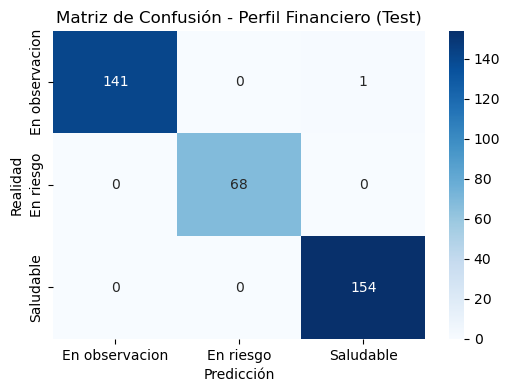

In [3]:
# Preprocesamiento (conversión numérica compatible con java)
mapeo_ahorro = {'Ninguna': 0.0, 'Baja': 1.0, 'Media': 2.0, 'Alta': 3.0}

# Servir los datos para el entrenamiento
# Preparar los datos brutos del CSV para que el algoritmo matemático pueda digerirlos antes de entrenar el modelo
def prepare_features(df):
    df_prep = df.copy() # Hace una copia de seguridad de la tabla de datos para no arruinar el archivo original
    df_prep['ahorro_num'] = df_prep['frecuencia_ahorro'].map(mapeo_ahorro) # traduce palabras a números
    return df_prep[['ingreso_mensual', 'nivel_endeudamiento', 'ahorro_num']], df_prep['perfil_financiero'] # separan la tabla en dos partes y devuelve features y labels

X_train_u, y_train_u = prepare_features(train_u)
X_val_u, y_val_u = prepare_features(val_u)
X_test_u, y_test_u = prepare_features(test_u)

# Entrenamiento (class_weight='balanced' para priorizar detección de 'en riesgo')
profiler_model = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=SEED) # subido el max depth de 5 a 8
profiler_model.fit(X_train_u, y_train_u)

# Evaluación ciega sobre set de validación y test
y_val_pred = profiler_model.predict(X_val_u)
y_test_pred = profiler_model.predict(X_test_u)

print("A)--- Reporte en VAL (Ajuste) ---")
print(classification_report(y_val_u, y_val_pred))

print("\nB)--- Reporte en TEST (calificación final) ---")
print(classification_report(y_test_u, y_test_pred))# Graficar matriz de confusión del perfil financiero
cm_prof = confusion_matrix(y_test_u, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_prof, annot=True, fmt='d', cmap='Blues', xticklabels=profiler_model.classes_, yticklabels=profiler_model.classes_)
plt.title('Matriz de Confusión - Perfil Financiero (Test)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()


## 3. Modelo 2: NLP para categorización de transacciones

Construcción de modelo de clasificación de texto conectando:
- TF-IDF (traductor de texto) para convertir las palabras de los tickets en números (con `stop_words=None` para evitar descargas en backend).
- Un algoritmo de regresión logística configurado con un límite alto de iteraciones (max_iter) para darle tiempo de procesar las faltas de ortografía inyectadas previamente.

### Y evaluación + métricas
Medir la precisión y el rendimiento de los modelos utilizando el set de datos de validación (los meses del año no vistos durante el entrenamiento). Dibujar matrices de confusión para auditar visualmente en qué categorías o perfiles específicos se está equivocando la IA.

--- Reporte NLP en VAL ---
                   precision    recall  f1-score   support

     Alimentacion       0.92      0.94      0.93      5942
        Educacion       0.91      0.83      0.87      2257
Electrodomesticos       0.91      0.85      0.88      2193
        Inversion       0.91      0.92      0.91      4015
             Ocio       0.91      0.91      0.91      4112
            Salud       0.90      0.82      0.86      2182
        Servicios       0.91      0.95      0.93      7551
       Transporte       0.91      0.91      0.91      4096
       Vestimenta       0.91      0.82      0.87      2160
         Vivienda       0.91      0.94      0.92      5794

         accuracy                           0.91     40302
        macro avg       0.91      0.89      0.90     40302
     weighted avg       0.91      0.91      0.91     40302


--- Reporte NLP en TEST ---
                   precision    recall  f1-score   support

     Alimentacion       0.91      0.94      0.93      5

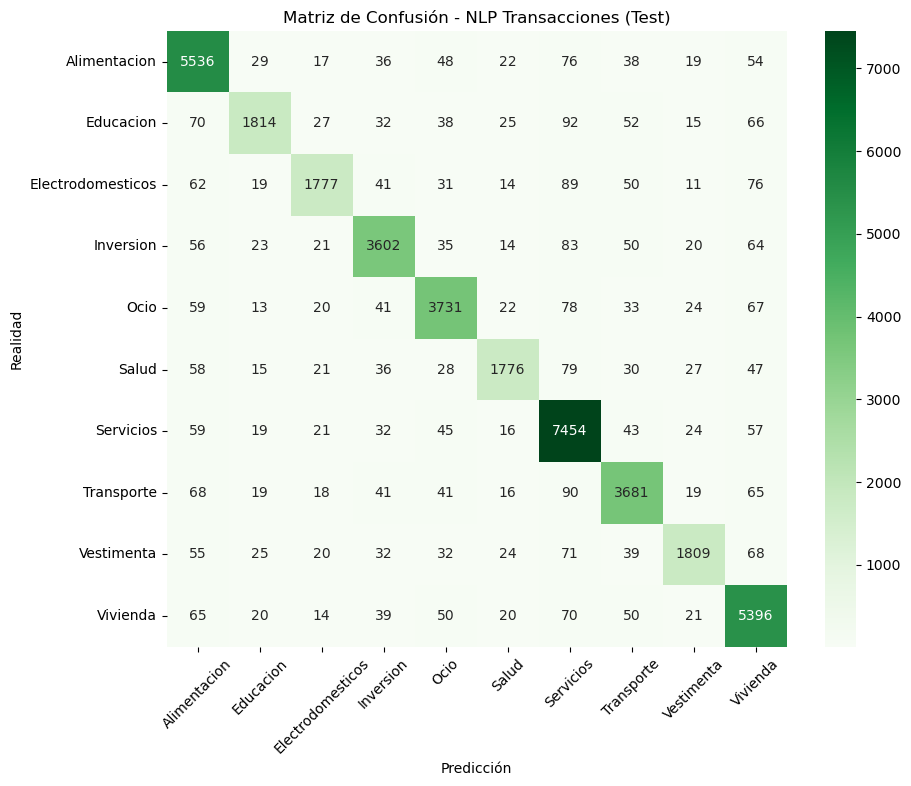

In [4]:
# Preparación de los textos de entrada. El pipeline procesa arreglos 1D en Python.
X_train_t = train_t['descripcion']
y_train_t = train_t['categoria']

X_val_t = val_t['descripcion']
y_val_t = val_t['categoria']

X_test_t = test_t['descripcion']
y_test_t = test_t['categoria']

# Pipeline Completo
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=None, max_features=1000)),
    ('clf', LogisticRegression(random_state=SEED, max_iter=500, class_weight='balanced')) # max_iter de 200 a 500
])

nlp_pipeline.fit(X_train_t, y_train_t)

y_val_pred_t = nlp_pipeline.predict(X_val_t)
y_test_pred_t = nlp_pipeline.predict(X_test_t)

print("--- Reporte NLP en VAL ---")
print(classification_report(y_val_t, y_val_pred_t))

print("\n--- Reporte NLP en TEST ---")
print(classification_report(y_test_t, y_test_pred_t))# Graficar matriz de confusión de Transacciones NLP
cm_nlp = confusion_matrix(y_test_t, y_test_pred_t)
plt.figure(figsize=(10,8))
sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='Greens', xticklabels=nlp_pipeline.classes_, yticklabels=nlp_pipeline.classes_)
plt.title('Matriz de Confusión - NLP Transacciones (Test)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.xticks(rotation=45)
plt.show()


## 4. Exportación ONNX y Contrato de Metadatos
Para garantizar la interoperabilidad con Spring Boot, se serializan los modelos y se genera un contrato JSON que especifique los tipos de datos de entrada/salida.

Se exportan ambos modelos terminados al formato universal ONNX. Este estándar empaqueta las matemáticas en un solo archivo, lo que permite que el equipo de backend pueda cargar la IA directamente en java sin necesidad de programar en python para producción.

In [5]:
os.makedirs('models', exist_ok=True)
os.makedirs('../shared-models', exist_ok=True)

# Exportar modelo perfil (espera matriz bidimensional de 3 floats)
initial_type_prof = [('float_input', FloatTensorType([None, 3]))]
onnx_prof = to_onnx(profiler_model, initial_types=initial_type_prof, target_opset=12)

# Exportar modelo NLP (espera array de strings)
# skl2onnx requiere shape [None, 1] para inputs tipo string desde pipelines
initial_type_nlp = [('string_input', StringTensorType([None, 1]))]
onnx_nlp = to_onnx(nlp_pipeline, initial_types=initial_type_nlp, target_opset=12)

for path in ['models/', '../shared-models/']:
    with open(f"{path}modelo_perfil.onnx", 'wb') as f:
        f.write(onnx_prof.SerializeToString())
    with open(f"{path}modelo_transacciones.onnx", 'wb') as f:
        f.write(onnx_nlp.SerializeToString())

print("Modelos exportados a models/ y shared-models/.")

Modelos exportados a models/ y shared-models/.


In [6]:
# Creación del metadata.json
# Se registran dinámicamente las clases del modelo para no codificarlas fijos (hardcode) en Java

metadata = {
    "model_version": "2.0.0",
    "categories": list(nlp_pipeline.classes_),
    "profiles": list(profiler_model.classes_),
    "transacciones_model": {
        "onnx_input_name": "string_input",
        "onnx_output_name": "output_label",
        "categories": list(nlp_pipeline.classes_)
    },
    "perfil_model": {
        "onnx_input_name": "float_input",
        "onnx_output_name": "output_label",
        "profiles": list(profiler_model.classes_)
    }
}

for path in ['models/', '../shared-models/']:
    with open(f"{path}metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Contrato de Metadatos creado y exportado:")
print(json.dumps(metadata, indent=2))

Contrato de Metadatos creado y exportado:
{
  "model_version": "2.0.0",
  "categories": [
    "Alimentacion",
    "Educacion",
    "Electrodomesticos",
    "Inversion",
    "Ocio",
    "Salud",
    "Servicios",
    "Transporte",
    "Vestimenta",
    "Vivienda"
  ],
  "profiles": [
    "En observacion",
    "En riesgo",
    "Saludable"
  ],
  "transacciones_model": {
    "onnx_input_name": "string_input",
    "onnx_output_name": "output_label",
    "categories": [
      "Alimentacion",
      "Educacion",
      "Electrodomesticos",
      "Inversion",
      "Ocio",
      "Salud",
      "Servicios",
      "Transporte",
      "Vestimenta",
      "Vivienda"
    ]
  },
  "perfil_model": {
    "onnx_input_name": "float_input",
    "onnx_output_name": "output_label",
    "profiles": [
      "En observacion",
      "En riesgo",
      "Saludable"
    ]
  }
}


## Prueba ONNX categorías

In [8]:
import onnxruntime as ort
import numpy as np

# Ya no necesitamos cargar el metadata.json porque ONNX ya sabe las palabras
session = ort.InferenceSession("../shared-models/modelo_transacciones.onnx")
input_name = session.get_inputs()[0].name

print(" Modelo ONNX cargado. Escribe una transacción para probar su inteligencia.")
print("Escribe 'salir' para terminar.\n")

while True:
    texto = input(" Ingresa un gasto (ej. 'compra super', 'cuota osde'): ")
    
    if texto.lower() == 'salir':
        break
        
    # Convertir el texto al formato matricial que espera ONNX
    input_data = np.array([[texto]], dtype=object)
    
    # Hacer la inferencia
    resultado = session.run(None, {input_name: input_data})
    
    # Como el modelo ya escupe el texto directo, simplemente lo imprimimos
    categoria = resultado[0][0]
    
    print(f" Inteligencia Artificial dice: {categoria}\n")

 Modelo ONNX cargado. Escribe una transacción para probar su inteligencia.
Escribe 'salir' para terminar.



 Ingresa un gasto (ej. 'compra super', 'cuota osde'):  salir


## Prueba de ONNX perfiles

* **Caso negativo:** Ingreso 1500, Deuda 50, Ahorro Ninguna. (Debería dar 'En riesgo').
* **Caso ideal:** Ingreso 4000, Deuda 15, Ahorro Alta. (Debería dar 'Saludable').
* **Caso engañoso:** Ingreso 5000 (mucho dinero), pero deuda 60 (gasta muchísimo en alquiler), ahorro 'Baja'. (El modelo debería ignorar que gana mucho dinero y enviarlo a 'En riesgo' por su mala gestión).

In [ ]:
import onnxruntime as ort
import numpy as np

# Cargar el "cerebro" ONNX del perfilador
session_perfil = ort.InferenceSession("../shared-models/modelo_perfil.onnx")
input_name_perfil = session_perfil.get_inputs()[0].name

print(" Modelo de Perfilado ONNX cargado.")
print("Simulemos la economía de un usuario. Escribe 'salir' en cualquier momento para terminar.\\n")

# Diccionario interno que usa tu modelo para entender el texto del ahorro
mapeo_ahorro = {'ninguna': 0.0, 'baja': 1.0, 'media': 2.0, 'alta': 3.0}

while True:
    ingreso = input(" 1. Ingreso mensual (ej. 2500): ")
    if ingreso.lower() == 'salir': break
        
    deuda = input(" 2. Nivel de endeudamiento % (ej. 45 para 45%): ")
    if deuda.lower() == 'salir': break
        
    ahorro = input(" 3. Hábito de ahorro (Ninguna, Baja, Media, Alta): ").lower()
    if ahorro == 'salir': break

    try:
        # Convertir los inputs humanos a números flotantes
        ingreso_float = float(ingreso)
        deuda_float = float(deuda)
        ahorro_float = mapeo_ahorro.get(ahorro, 0.0) # Si escribe mal, asume Ninguna
        
        # ONNX exige una matriz 2D de tipo float32 estricto
        input_data = np.array([[ingreso_float, deuda_float, ahorro_float]], dtype=np.float32)
        
        # Hacer la inferencia
        resultado = session_perfil.run(None, {input_name_perfil: input_data})
        
        # Extraer el veredicto
        perfil_asignado = resultado[0][0]
        
        print(f"\n Diagnóstico de la IA: Usuario {perfil_asignado}\n")
        print("-" * 40)
        
    except ValueError:
        print("\n Error: Asegúrate de ingresar números válidos en Ingreso y Deuda.\n")